# Cats vs Dogs using simple CNN + Drop out + Augmentation

## 1. Define the Data Generators


In [1]:
from keras.utils import image_dataset_from_directory
import os

# set up the paths and dataset 

base_dir = '..\\dogsVcats'

train_dir = os.path.join(base_dir,'train')
test_dir = os.path.join(base_dir,'test')
val_dir = os.path.join(base_dir,'validation')

batch_size = 32
image_size = (150,150)

train_dataset = image_dataset_from_directory(train_dir, image_size=image_size, batch_size=batch_size)
validation_dataset = image_dataset_from_directory(val_dir, image_size=image_size, batch_size=batch_size)
test_dataset = image_dataset_from_directory(test_dir, image_size=image_size, batch_size=batch_size)

epochs = 80


Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 1001 files belonging to 2 classes.


## 2. Test the generators

In [2]:



for data_batch, label_batch in train_dataset:
    print('data batch shape ', data_batch.shape)
    print('label batch shape ', label_batch.shape)
    print('sample data shape ', data_batch[1].shape)
    print('sample labels ', label_batch)
               
    break
    

data batch shape  (32, 150, 150, 3)
label batch shape  (32,)
sample data shape  (150, 150, 3)
sample labels  tf.Tensor([0 1 0 1 0 1 1 1 1 1 0 1 0 1 0 0 1 1 0 1 0 1 0 0 1 1 1 0 0 0 0 0], shape=(32,), dtype=int32)


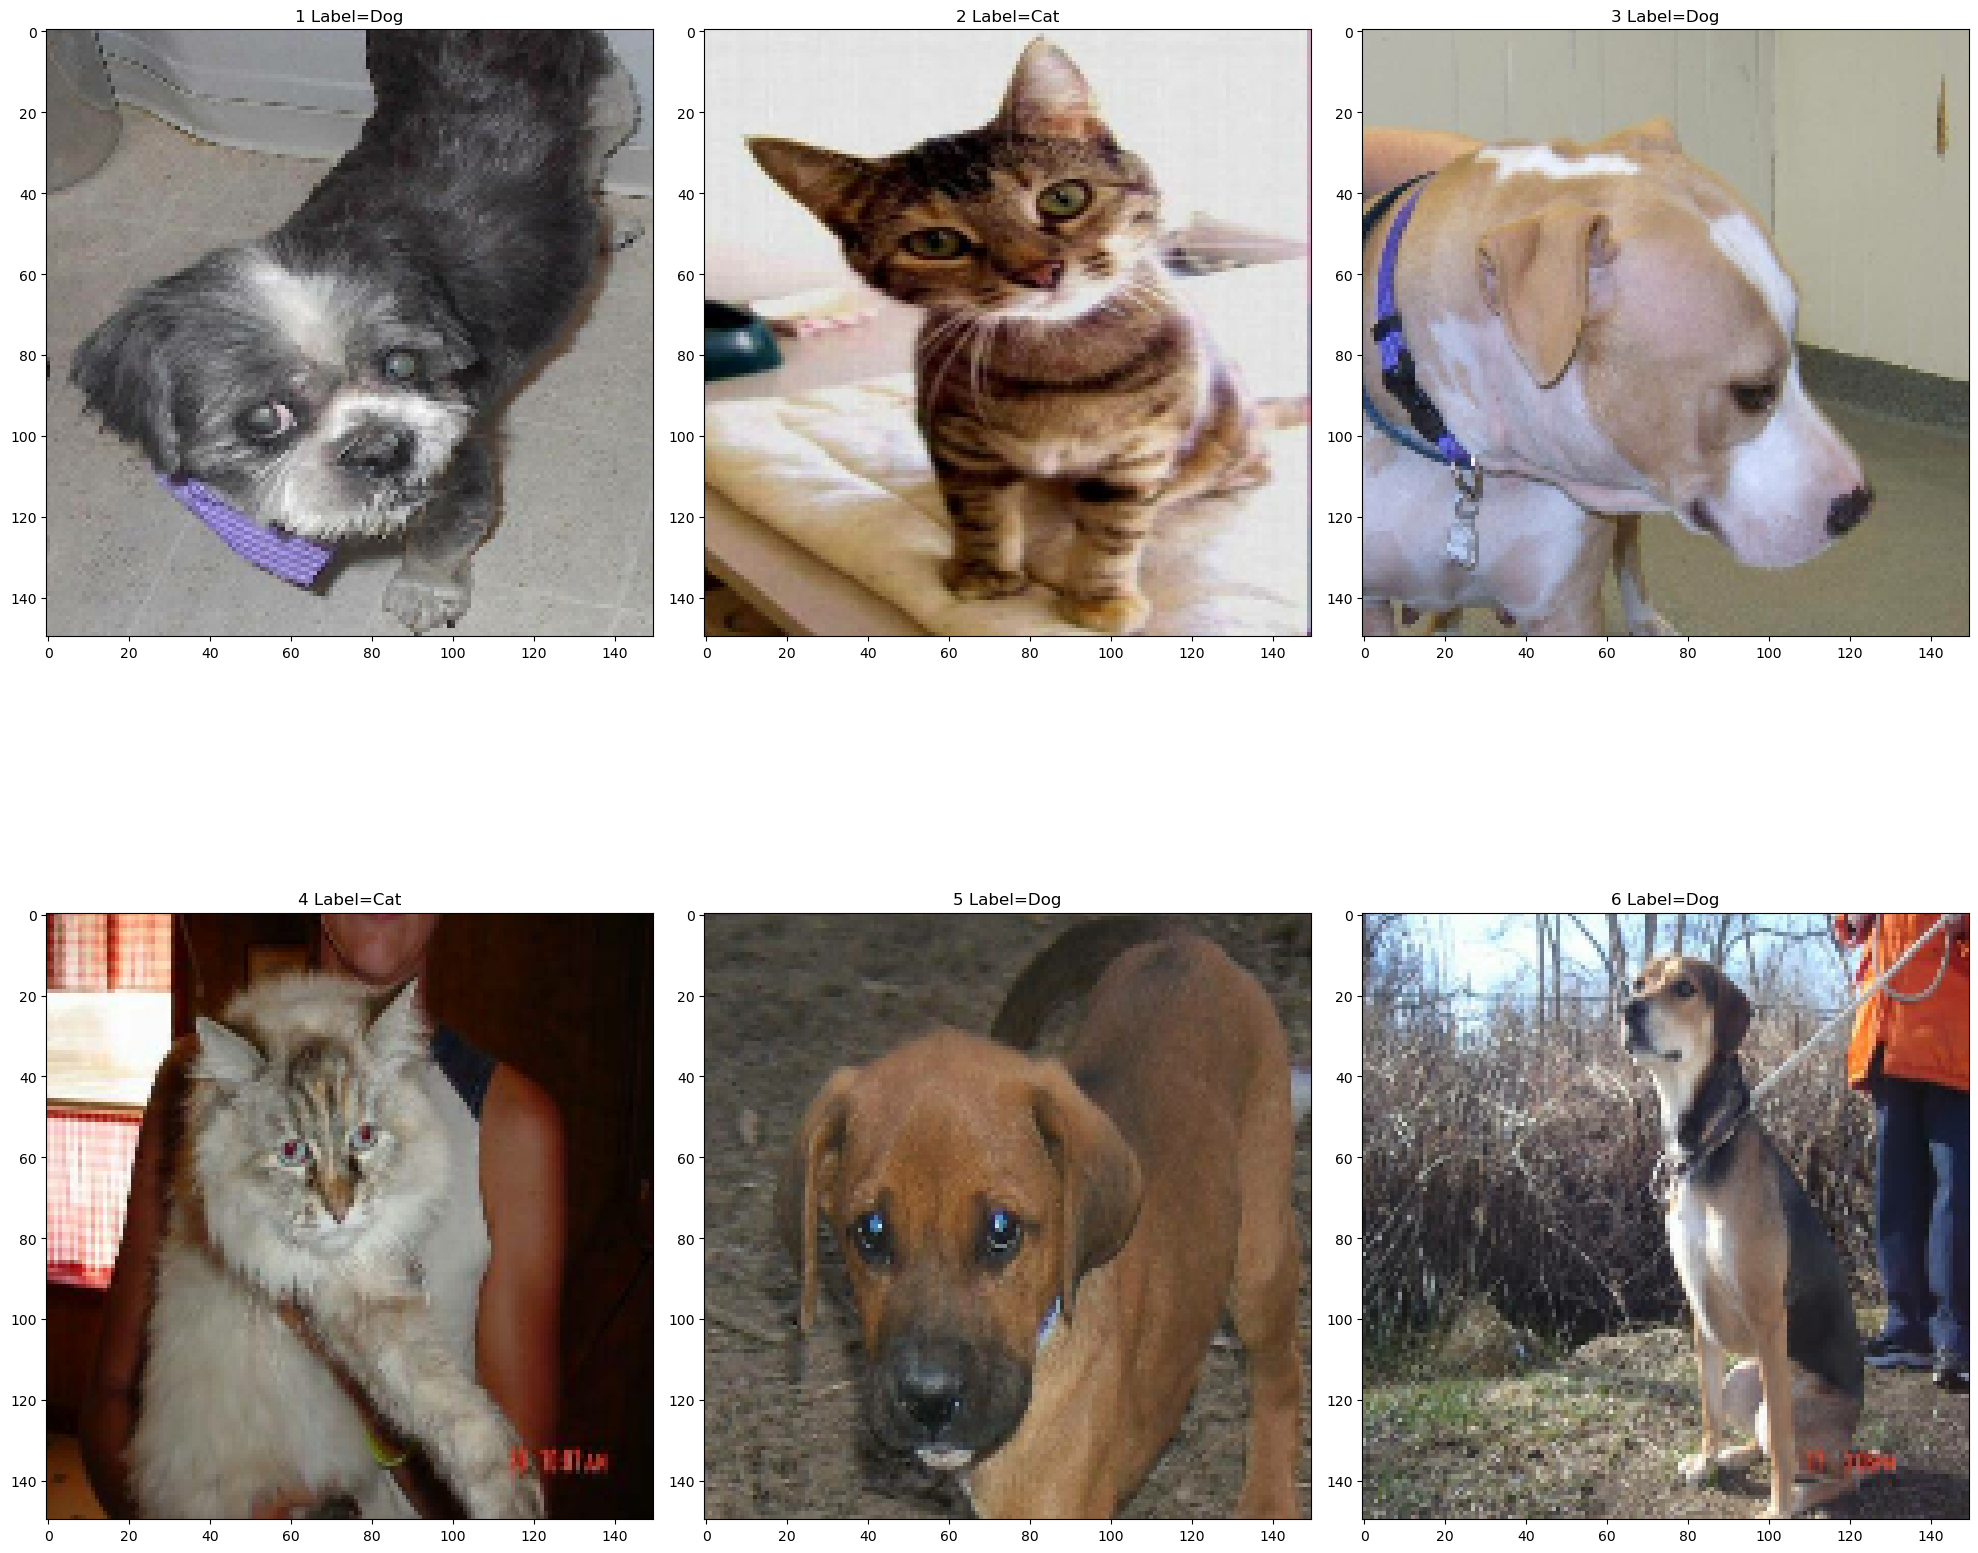

In [3]:
import matplotlib.pyplot as plt
fig=plt.figure(figsize=(20,20))
columns = 3
rows = 2
for i in range(1, 7):
    img = data_batch[i]/255
    ax =fig.add_subplot(rows, columns, i)
    if label_batch[i] == 0: lbl = "Cat"
    else: lbl = "Dog"
    fig.tight_layout()
    ax.title.set_text(str(i)+ " Label=" + lbl)
    plt.imshow(img)
plt.show()

## 3.  Define the network without augmentation

In [4]:
from keras import models, layers

network = models.Sequential()
network.add(layers.Input(shape= (150,150,3)))
network.add(layers.Rescaling(1.0/255))
network.add(layers.Conv2D(32, (3,3), activation='relu'))
network.add(layers.MaxPooling2D(2,2))
network.add(layers.Conv2D(64, (3,3), activation='relu'))
network.add(layers.MaxPooling2D(2,2))
network.add(layers.Conv2D(128,(3,3), activation='relu'))
network.add(layers.MaxPooling2D(2,2))
network.add(layers.Conv2D(256,(3,3), activation='relu'))
network.add(layers.MaxPooling2D(2,2))
network.add(layers.Conv2D(512,(3,3), activation='relu'))
network.add(layers.GlobalAveragePooling2D())    
network.add(layers.Dense(1,activation='sigmoid'))

network.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 15, 15, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 7, 7, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 5, 5, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,569,089 (5.99 MB)

 Trainable params: 1,569,089 (5.99 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Compile and Train

In [5]:
#from tensorflow.keras import optimizers
from keras import callbacks

#callbacks help to save intermediate results.

callbacks = [callbacks.ModelCheckpoint(
                filepath = "convnet_for_cats.keras",
                save_best_only=True,
                monitor="val_loss")
            ]

# network.compile(loss='binary_crossentropy', optimizer=optimizers.RMSprop(learning_rate=1e-4), metrics=['acc']) # alternative showing use of learning rate
network.compile(loss='binary_crossentropy', optimizer="adam", metrics=['acc'])
history = network.fit(train_dataset,  epochs=epochs, validation_data=validation_dataset,callbacks=callbacks)


Epoch 1/80
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 202ms/step - acc: 0.5035 - loss: 0.6957 - val_acc: 0.5010 - val_loss: 0.6931
Epoch 2/80
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 198ms/step - acc: 0.5230 - loss: 0.6923 - val_acc: 0.5000 - val_loss: 0.6948
Epoch 3/80
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 195ms/step - acc: 0.5275 - loss: 0.6890 - val_acc: 0.5680 - val_loss: 0.6788
Epoch 4/80
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 196ms/step - acc: 0.5930 - loss: 0.6659 - val_acc: 0.6330 - val_loss: 0.6646
Epoch 5/80
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 195ms/step - acc: 0.6295 - loss: 0.6468 - val_acc: 0.5950 - val_loss: 0.6514
Epoch 6/80
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 201ms/step - acc: 0.6395 - loss: 0.6310 - val_acc: 0.6490 - val_loss: 0.6190
Epoch 7/80
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 189ms/step - acc: 0.6740 - loss: 0.6113 - val_acc: 0.6450 - val_loss: 0.6194
Epoch 8/80
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 197ms/step - acc: 0.6675 - loss: 0.6076 - val_acc: 0.7000 - val_loss: 0.5904
Epoch 9/80
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 194ms/

# 7. Model with Dropout


In [6]:
network_drop = models.Sequential()
network_drop.add(layers.Input(shape= (150,150,3)))
network_drop.add(layers.Rescaling(1.0/255))
network_drop.add(layers.Conv2D(32, (3,3), activation='relu'))
network_drop.add(layers.MaxPooling2D(2,2))
network_drop.add(layers.Conv2D(64, (3,3), activation='relu'))
network_drop.add(layers.MaxPooling2D(2,2))
network_drop.add(layers.Conv2D(128,(3,3), activation='relu'))
network_drop.add(layers.MaxPooling2D(2,2))
network_drop.add(layers.Conv2D(256,(3,3), activation='relu'))
network_drop.add(layers.MaxPooling2D(2,2))
network_drop.add(layers.Conv2D(512,(3,3), activation='relu'))
network_drop.add(layers.GlobalAveragePooling2D()) 
network_drop.add(layers.Dropout(0.4))
network_drop.add(layers.Dense(1,activation='sigmoid'))
network_drop.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)              │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 15, 15, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 7, 7, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 5, 5, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,569,089 (5.99 MB)

 Trainable params: 1,569,089 (5.99 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
from keras import callbacks
callbacks_drop = [callbacks.ModelCheckpoint(
                filepath = "convnet_for_cats_drop.keras",
                save_best_only=True,
                monitor="val_loss")
            ]
network_drop.compile(loss='binary_crossentropy', optimizer="adam", metrics=['acc'])
history_drop = network_drop.fit(train_dataset,  epochs=epochs, validation_data=validation_dataset,callbacks=callbacks_drop)

Epoch 1/80
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 214ms/step - acc: 0.4920 - loss: 0.6965 - val_acc: 0.5010 - val_loss: 0.6898
Epoch 2/80
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 217ms/step - acc: 0.5025 - loss: 0.6930 - val_acc: 0.5000 - val_loss: 0.6888
Epoch 3/80
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 208ms/step - acc: 0.5410 - loss: 0.6867 - val_acc: 0.6050 - val_loss: 0.6706
Epoch 4/80
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 198ms/step - acc: 0.6010 - loss: 0.6687 - val_acc: 0.5470 - val_loss: 0.6745
Epoch 5/80
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 195ms/step - acc: 0.5975 - loss: 0.6649 - val_acc: 0.6160 - val_loss: 0.6480
Epoch 6/80
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 211ms/step - acc: 0.6385 - loss: 0.6356 - val_acc: 0.6840 - val_loss: 0.6055
Epoch 7/80
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 197ms/step - acc: 0.6690 - loss: 0.6122 - val_acc: 0.6870 - val_loss: 0.5920
Epoch 8/80
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 199ms/step - acc: 0.7030 - loss: 0.5861 - val_acc: 0.6610 - val_loss: 0.6305
Epoch 9/80
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 200ms/

# 8. Model with Data Augmentation

In [8]:
network_aug = models.Sequential()
network_aug.add(layers.Input(shape= (150,150,3)))
network_aug.add(layers.RandomFlip("horizontal"))
network_aug.add(layers.RandomRotation(0.1))
network_aug.add(layers.RandomZoom(0.2))
network_aug.add(layers.Rescaling(1.0/255))
network_aug.add(layers.Conv2D(32, (3,3), activation='relu'))
network_aug.add(layers.MaxPooling2D(2,2))
network_aug.add(layers.Conv2D(64, (3,3), activation='relu'))
network_aug.add(layers.MaxPooling2D(2,2))
network_aug.add(layers.Conv2D(128,(3,3), activation='relu'))
network_aug.add(layers.MaxPooling2D(2,2))
network_aug.add(layers.Conv2D(256,(3,3), activation='relu'))
network_aug.add(layers.MaxPooling2D(2,2))
network_aug.add(layers.Conv2D(512,(3,3), activation='relu'))
network_aug.add(layers.GlobalAveragePooling2D()) 
network_aug.add(layers.Dropout(0.4))
network_aug.add(layers.Dense(1,activation='sigmoid'))
network_aug.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)             │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_rotation (RandomRotation)     │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_zoom (RandomZoom)             │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling_2 (Rescaling)              │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 15, 15, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 7, 7, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 5, 5, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,569,089 (5.99 MB)

 Trainable params: 1,569,089 (5.99 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:

callbacks_aug = [callbacks.ModelCheckpoint(
                filepath = "convnet_for_cats_aug.keras",
                save_best_only=True,
                monitor="val_loss")
            ]
network_aug.compile(loss='binary_crossentropy', optimizer="adam", metrics=['acc'])
history_aug = network_aug.fit(train_dataset,  epochs=epochs, validation_data=validation_dataset,callbacks=callbacks_aug)

Epoch 1/80
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 212ms/step - acc: 0.8545 - loss: 0.3311 - val_acc: 0.7790 - val_loss: 0.5871
Epoch 2/80
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 211ms/step - acc: 0.8505 - loss: 0.3323 - val_acc: 0.8130 - val_loss: 0.4142
Epoch 3/80
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 204ms/step - acc: 0.8660 - loss: 0.3109 - val_acc: 0.7940 - val_loss: 0.4664
Epoch 4/80
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 203ms/step - acc: 0.8470 - loss: 0.3407 - val_acc: 0.7560 - val_loss: 0.6373
Epoch 5/80
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 226ms/step - acc: 0.8650 - loss: 0.3150 - val_acc: 0.8220 - val_loss: 0.3936
Epoch 6/80
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 221ms/step - acc: 0.8735 - loss: 0.2863 - val_acc: 0.8130 - val_loss: 0.5066
Epoch 7/80
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 219ms/step - acc: 0.8730 - loss: 0.3041 - val_acc: 0.7880 - val_loss: 0.5541
Epoch 8/80
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 208ms/step - acc: 0.8720 - loss: 0.3066 - val_acc: 0.7760 - val_loss: 0.5346
Epoch 9/80
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 211ms/

# Results

In [11]:
import matplotlib.pyplot as plt

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

acc_drop = history_drop.history['acc']
val_acc_drop = history_drop.history['val_acc']
loss_drop = history_drop.history['loss']
val_loss_drop = history_drop.history['val_loss']


acc_aug = history_aug.history['acc']
val_acc_aug = history_aug.history['val_acc']
loss_aug = history_aug.history['loss']
val_loss_aug = history_aug.history['val_loss']

epochs_list = range(1,len(acc)+1)




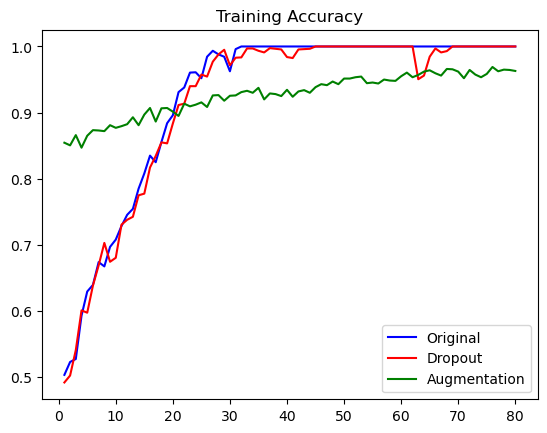

In [12]:
plt.plot(epochs_list, acc, 'b', label='Original')
plt.plot(epochs_list, acc_drop, 'r', label='Dropout')
plt.plot(epochs_list, acc_aug, 'g', label='Augmentation')
plt.title('Training Accuracy')
plt.legend()
plt.show()

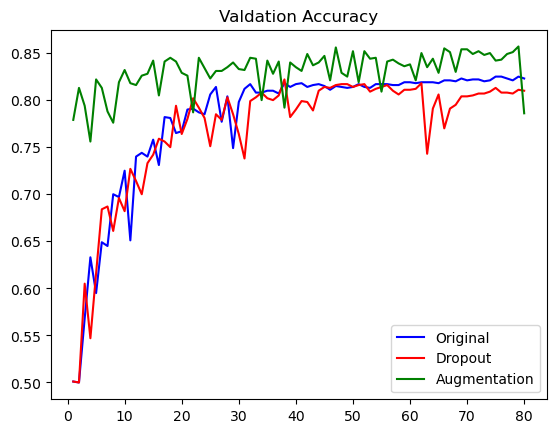

In [13]:
plt.plot(epochs_list, val_acc, 'b', label='Original')
plt.plot(epochs_list, val_acc_drop, 'r', label='Dropout')
plt.plot(epochs_list, val_acc_aug, 'g', label='Augmentation')
plt.title('Valdation Accuracy')
plt.legend()
plt.show()

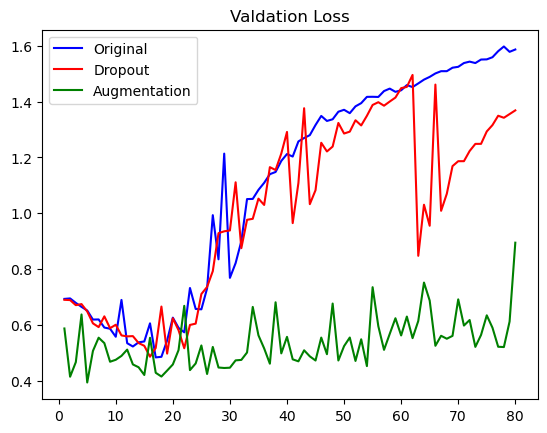

In [14]:
plt.plot(epochs_list, val_loss, 'b', label='Original')
plt.plot(epochs_list, val_loss_drop, 'r', label='Dropout')
plt.plot(epochs_list, val_loss_aug, 'g', label='Augmentation')
plt.title('Valdation Loss')
plt.legend()
plt.show()

In [15]:
from keras import models
test_model = models.load_model("convnet_for_cats.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)

test_model_aug = models.load_model("convnet_for_cats_aug.keras")
test_loss_aug, test_acc_aug = test_model_aug.evaluate(test_dataset)
 
test_model_drop = models.load_model("convnet_for_cats_drop.keras")
test_loss_drop, test_acc_drop = test_model_drop.evaluate(test_dataset)

print(f"Accuracy without augmentation  = {test_acc:.3f}")
print(f"Accuracy with augmeneetation  = {test_acc_aug:.3f}")
print(f"Accuracy with dropout = {test_acc_drop:.3f}")




32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - acc: 0.7762 - loss: 0.5130
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - acc: 0.8002 - loss: 0.4584
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - acc: 0.7762 - loss: 0.4965
Accuracy without augmentation  = 0.776
Accuracy with augmeneetation  = 0.800
Accuracy with dropout = 0.776
